**41040 Introduction To Artificial Intelligence Assignment 2 Notebook** \
For the teams second Assignment for intro to Ai we decided to use Google collab to solve our Weather classification problem. The team aims to test a range of Ai algorithms in classifying weather data into Sunny, Windy, Rainy or Stormy days using the following notebook. After evaluating these techniques we will be able to justify a suitable algorithm that can be used to solve our target problem.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
#Authorises the notebook to gain access to files within our google drive allowing it to access our weather.csv dataset.

Mounted at /content/drive


The cd command will open up and access the contents of the specific folder the data is stored.

In [ ]:
cd /content/drive/MyDrive/Intro to Ai Assignment 2

/content/drive/MyDrive/Intro to Ai Assignment 2


#Preparing the dataset

In [ ]:
#The following code will allow us to access specific libraries we will use to create to solve our target problem.
import pandas as pd
#Imports the pandas library as pd allowing us to access data and analyse it.
import matplotlib.pyplot as plt
#Imports the pyplot module from the matplotlib library as plt allowing us to plot and visualise our datset.
import seaborn as sns
#Imports the Seaborn library as sns assisting with making graphs.

In [ ]:
weather = pd.read_csv('weather_forecast_data.csv')
#Creates the variable weather and assigns it to the weather data.
#Uses the pd library to read the weather forecast data csv file

In [ ]:
weather.head(5)
#Prints the first 5 rows of the weather forecast csv file.
#This code was used to validate that the file had been imported and was connected to the weather variable.

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain
0,23.720338,89.592641,7.335604,50.501694,1032.378759,rain
1,27.879734,46.489704,5.952484,4.990053,992.614190,no rain
2,25.069084,83.072843,1.371992,14.855784,1007.231620,no rain
3,23.622080,74.367758,7.050551,67.255282,982.632013,rain
4,20.591370,96.858822,4.643921,47.676444,980.825142,no rain


In [ ]:
# The following code is the main function that is used which will assign a classification based on field names of our datset.
def Weather_Classification(row):
    if row['Rain'] == 'no rain' and row['Temperature'] > 20 and row['Cloud_Cover'] < 30:
        return 'Sunny'
        #The first line of code checks whether the rain column has no rain, the cloud coverage is less than 30 and the temperature is greater than 20 degrees.
        #If these conditions are true the function will return a Sunny day due to high temperatures, less clouds obstructing and a warm temperature.
    elif row['Humidity'] > 60 and row['Humidity'] < 79 and row['Cloud_Cover'] > 50 and row['Cloud_Cover'] < 69 and row['Rain'] == 'rain':
          return 'Rainy'
        #Else if the first condition is not satisfied it will check for rainy weather.
        #If Humidity is higher then 60%, cloud coverage is greater then 50 and there is rain the day would be classified as a rainy day.
        #As humidity is the result of rain and moisture in the air having over 60% humidity, A cloud coverage of greater then 50 and rain occured.
        #The weather can be classified as Rainy.
    elif row['Humidity'] > 80 and row['Cloud_Cover'] > 70 and row['Rain'] == 'rain' and row['Temperature'] < 20 and row['Wind_Speed'] > 5:
          return 'Storm'
        #If the Humidity is greater than 80%, greater the 70 cloud coverage, there is Rain, temperature is less than 20 degrees and wind speed is greater than 5.
        #The weather would be classified as Storm.
    else:
      return 'Cloudy'
      #The else statement is used when none of the conditions can be fully satisfied.
      #In this case the function would categorise these days as just cloudy.

In [ ]:
weather['Weather_Intensity'] = weather.apply(Weather_Classification, axis=1)
#Apply the classification function to create a new target variable.
#Set the Axis to be 1 to apply the function to each row.

In [ ]:
X = weather[['Temperature', 'Humidity', 'Wind_Speed', 'Cloud_Cover', 'Pressure']]
#Create the variable X and set its features to be the fields within the datset.
#In this case the features would be 'Temperature', 'Humidity', 'Wind_Speed', 'Cloud_Cover', 'Pressure'.
#The features are then used to provide the information for the model to make predictions and classifications.
y = weather['Weather_Intensity']
#Create the varaible y and make the target varaiables the weather intensity.
#In this case the target varaible is the 'Weather_Intensity'.
#The target variable is the output that you want to predict or classify as.

In [ ]:
from sklearn.model_selection import train_test_split
#Imports the train_test_split function from the sklearn library which will be used for splitting datasets.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Using train_test_split function we proceeded to split the datasets into training and testing datsets.
#The percentage of samples to test is set at 20% and the remaing 80% is used for training the dataset.
#The seed for the random number generator is 42 for everything to stay consistent.

#**Humidity Vs Temperature**

The following code uses the Matplot library to create a scatter graph showing the correlation between Temperature and Humidity levels. This graph is useful as humidity and temperature correlate to intensity of weather with higher levels of humidity or lower temperatures having a direct effect in weather conditions. Below the scatter plot aims to visualise their relationship and allow us to see the split between the training and test sets.

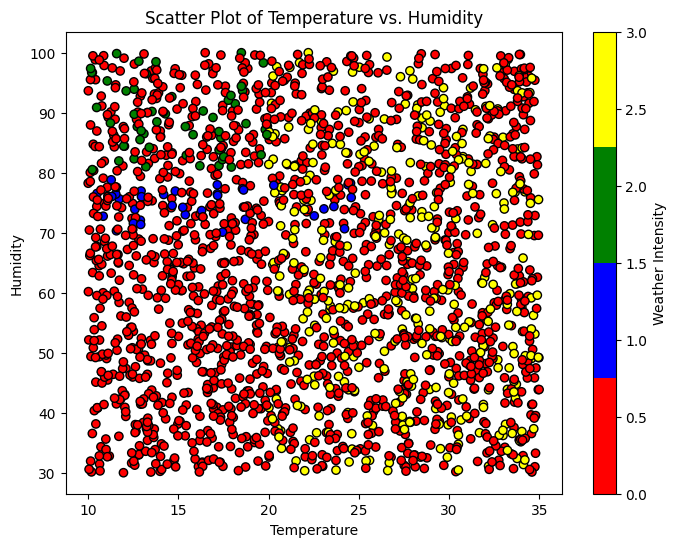

In [ ]:
from sklearn.preprocessing import LabelEncoder
#Imports the label encoder from sklearn.preprocessing.
from matplotlib.colors import ListedColormap
#Imports the ListedColormap from matplotlib.colors to access colours to better visualise the graph.

LabelEncoder = LabelEncoder()
#Creates a label encoder.
y_train_encoded = LabelEncoder.fit_transform(y_train)
#Encodes the categorical target variable Weather_Intensity into numeric values making them usable for the scatter plot.
Plot_colours = ListedColormap(['red', 'blue', 'green', 'yellow'])
#Sets up the colours to be used for the colour bar.
plt.figure(figsize=(8, 6))
#Sets up the size of the figure.
plt.scatter(X_train['Temperature'], X_train['Humidity'], c=y_train_encoded, cmap=Plot_colours, edgecolor="k")
#Specifies the X axis to be temperature and the y axis to be the humidity.
#Takes the label encoded data and assigns a numerical value to String outputs for example 0 = cloudy.
#We assign cmap to be the colours we cant to use for the colourbar.
#sets the edgecolour to black represented by 'K'
plt.xlabel('Temperature')
#Sets the X label to be Temperature.
plt.ylabel('Humidity')
#Sets the Y label to be Humidity.
plt.title('Scatter Plot of Temperature vs. Humidity')
#Sets the title of the scatter plot to be Temperature vs. Humidity.
plt.colorbar(label='Weather Intensity')
#creates the colour bar to show the key of the scatterplots ranging from 0 to 2.
plt.show()
#Shows the plot.

Key:\
Red = Cloudy\
Blue = Rainy\
Green = Storm\
Yellow = Sunny\
Evaluating the graph we can see observe that high humidity and lower temperatures tend to correlate with High intensity, indicating conditions that often result in rainy or stormy weather. We can also determine that the area experienced a higher amount of cloudy and sunny days compared to rainy and stormy days.


#**Training Classification models**
The following section below aims to test a range of AI techniques to evaluate which model is best for predicting weather intensity. The chosen techniques are Logistic regression, SVM and Decsion trees. By evaluating their accuracy we will determine which one is the most optimal technique.

Testing Different Classification Algorithm:


1.   Logistic Regression
2.   SVM
3.   Decision Trees



In [ ]:
from sklearn.tree import DecisionTreeClassifier
#Imports the DecisionTreeClassifier from sklearn.tree
from sklearn.linear_model import LogisticRegression
#Imports LogisticRegression from sklearn.linear_model
from sklearn.svm import SVC
#Import SVC sklearn.svm for SVM
from sklearn.metrics import classification_report, confusion_matrix
#Imports classification_report, confusion_matrix from sklearn.metrics
from sklearn.metrics import accuracy_score
#Imports accuracy_score from sklearn.metrics.

In [ ]:
LogisticRegression = LogisticRegression(max_iter=10000)
#creates a variable logistic regression to variable logistic regression
#Sets the max iteration to be 10000 so it doesnt run out of iterations
LogisticRegression.fit(X_train, y_train)
#the logistic regression takes in the X_train and y_train
y_pred = LogisticRegression.predict(X_test)
#Uses the trained Logistic Regression model to predict the target variable for the test dataset X_test

In [ ]:
score_test = accuracy_score(y_test, y_pred)
#Creates a accuracy test taking in the y_test and y_pred
#Compares the true labels y_test to the predicted labels y_pred
print (score_test)
#Prints the accuracy test

0.898


In [ ]:
classifier = SVC(gamma='auto',probability=True)
#creates a classifier for SVM with the classifier variable.
#The gamma is set to auto to specify gamma parameter for the kernel function
#probability = true means probabilities for predictions using the predict_proba method.
classifier.fit(X_train, y_train)
#The classifier takes in the X_train and y_train
y_pred = classifier.predict(X_test)
#Uses the trained SVM model to predict the target variable for the test dataset X_test

In [ ]:
score_test = accuracy_score(y_test, y_pred)
#Creates a accuracy test taking in the y_test and y_pred
#Compares the true labels y_test to the predicted labels y_pred
print (score_test)
#Prints the accuracy test

0.742


In [ ]:
Decisiontree = DecisionTreeClassifier(random_state=42)
#Creates the Variable Decisiontree and assigns it to the DecisionTreeClassifier.
#Sets the random state to be 42 to keep consistent
Decisiontree.fit(X_train, y_train)
#The decision tree classifier takes in the X_train and y_train
y_pred = Decisiontree.predict(X_test)
#Uses the trained decision tree model to predict the target variable for the test dataset X_test

In [ ]:
score_test = accuracy_score(y_test, y_pred)
#Creates a accuracy test taking in the y_test and y_pred
#Compares the true labels y_test to the predicted labels y_pred
print (score_test)
#Prints the accuracy test

0.996


#**Best Classifier**

After evaluating and testing all AI techniques we have justified our choice in using the **Decsion Tree** classifier as it has a 99.6% accuracy in predicting weather instensity for our datset.





In [ ]:
from sklearn import metrics
#Imports metrics from sklearn.
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
#Imports ConfusionMatrixDisplay, confusion_matrix from sklearn.metrics.
from sklearn.metrics import classification_report, confusion_matrix
#Imports classification_report, confusion_matrix from sklearn.metrics.

In [ ]:
precision_test = metrics.precision_score(y_test, y_pred, average='weighted', zero_division=1)
#The precision test takes in both the y_test, y_pred.
#Sets the average to weighted calculates precision for each class then calculates the average.
#Sets zero divison to 1 which fixes the calculation when there is a division by zero.
print (precision_test)
#Prints the precision test

0.9960214477211796


In [ ]:
recall_test = metrics.recall_score(y_test, y_pred, average='weighted')
#The recalltest takes in both the y_test, y_pred.
#Sets the average to weighted, which calculates recall for each class and then averages it.
#Provides a more balanced measure of recall when there are multiple classes.
print (recall_test)
#Prints recall Test.

0.996


In [ ]:
f1_test =  metrics.f1_score(y_test, y_pred, average='weighted')
#The f1 test takes in both the y_test, y_pred.
#Sets the average to weighted, which calculates f1 score for each class and then averages it.
#The f1 test provides a balance between the two metrics by providing the average of the precison and recall test.
print(f1_test)
#Prints the f1 score.

0.9957553763440861


In [ ]:
print("\nClassification Report:")
#Prints the Classification Report on a new line for each class.
print(classification_report(y_test, y_pred, zero_division=1))
#calculates various classification metrics such as precision, recall, F1 score, and support for each class.
#Sets zero divison to 1 which fixes the calculation when there is a division by zero.


Classification Report:
              precision    recall  f1-score   support

      Cloudy       0.99      1.00      1.00       371
       Rainy       1.00      0.78      0.88         9
       Storm       1.00      1.00      1.00        10
       Sunny       1.00      1.00      1.00       110

    accuracy                           1.00       500
   macro avg       1.00      0.94      0.97       500
weighted avg       1.00      1.00      1.00       500



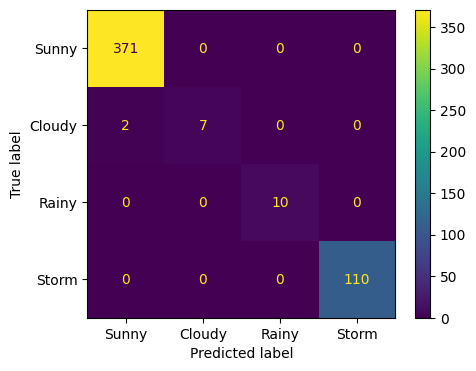

In [ ]:
fig,ax = plt.subplots(figsize=(5,4),dpi = 100)
#Creates a new figure and axis for the plot.
#The size of the plot is set to 5x4.
#The resolution (DPI) to 100.
cm = confusion_matrix(y_test, y_pred)
#The confusion matrix takes in both the y_test, y_pred.
#Helps evaluate the accuracy of a classification model.
cmp = ConfusionMatrixDisplay(cm, display_labels = ["Sunny", "Cloudy", "Rainy", "Storm"])
#Creates the confusion matrix objects.
#Takes in the cm we initialised before.
#Sets the display Labels as "Sunny", "Cloudy", "Rainy", "Storm" for the Axis.
cmp.plot(ax = ax);
#Plots the confusion matrix in a heatmap with the display labels initialised before.